In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# DATA LOAD

data = pd.read_csv("/content/Titanic-Dataset.csv")

In [3]:
df = pd.DataFrame(data)


In [4]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
# DATA CLAENING AND PREPROCESING

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
# MISSING VAUE HANDLE

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=['Cabin'],inplace=True)

df.drop(columns=['PassengerId','Name','Ticket'],inplace=True)

In [10]:
# EDA

df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


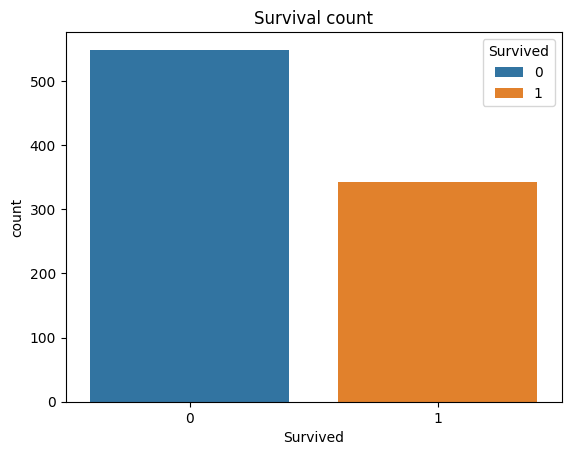

In [11]:
sns.countplot(x='Survived', hue= 'Survived', data=df)
plt.title("Survival count")
plt.show()

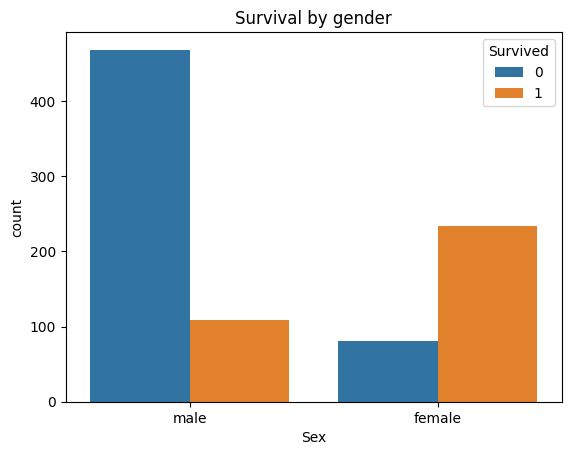

In [12]:
# Gender vs Survival

sns.countplot(x='Sex', hue= 'Survived', data=df)
plt.title("Survival by gender")
plt.show()

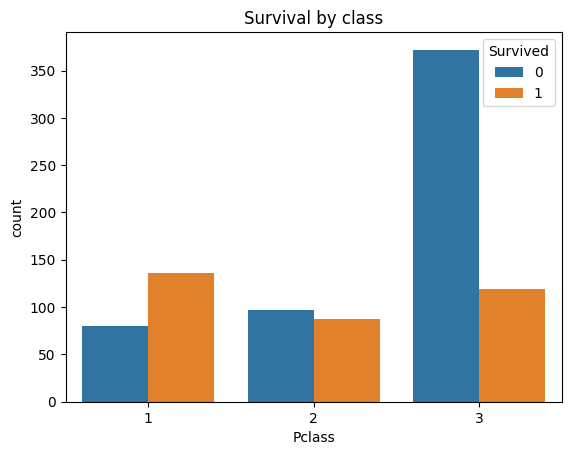

In [13]:
sns.countplot(x='Pclass', hue= 'Survived', data=df)
plt.title("Survival by class")
plt.show()

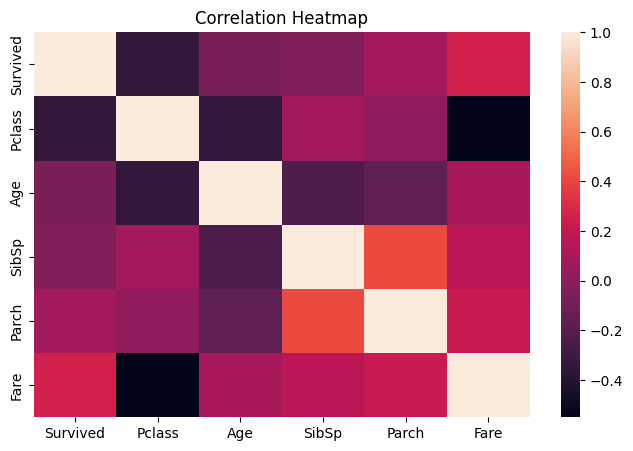

In [14]:
# Correlation Heatmap

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True))
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# Encoding

df['Sex'] = df['Sex'].map({'male' : 0,  'female' : 1})
df = pd.get_dummies(df, columns =['Embarked'],drop_first =True)

In [16]:
# X,Y Separate

X = df.drop(columns = ['Survived'])
y = df['Survived']

In [17]:
# train -Test Split

from sklearn.model_selection import train_test_split

X_train, X_test , y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42, stratify=y
)

In [18]:
# Features Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Model Train

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_model = LogisticRegression(max_iter= 1000)
log_model.fit(X_train_scaled,y_train)

rf_model= RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [20]:
# Prediction

y_pred_log = log_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

In [21]:
# Evalution

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Logistic Regression Accuracy:" , accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Report:\n",classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.8044692737430168
Random Forest Accuracy: 0.8044692737430168

Random Forest Report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



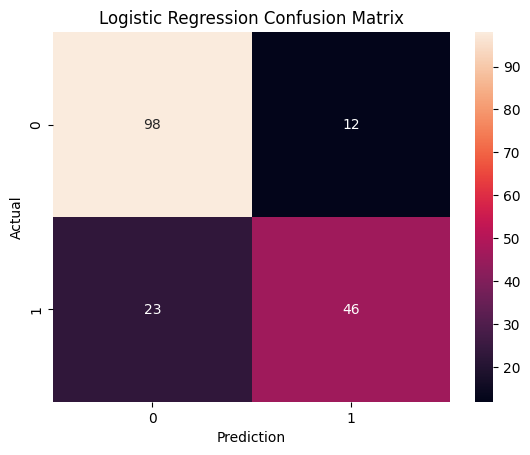

In [22]:
# Confusion Report

cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot= True, fmt= 'd')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

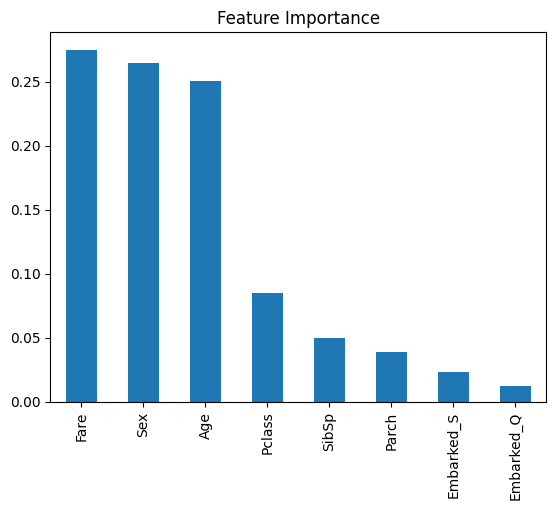

In [23]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances . plot(kind="bar", title="Feature Importance")
plt.show()

In [26]:
# test sample

new_passenger = pd.DataFrame({
    'Pclass': [3],
    'Sex': [1], # male= 0, female = 1
    'Age': [60],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked_Q': [0],
    'Embarked_S': [1]
})


new_passenger = new_passenger[X.columns]

prediction = rf_model.predict(new_passenger)

print("Survived" if prediction[0]==1 else "Not Survived")


Not Survived


In [27]:
# Save model

import joblib
joblib.dump(rf_model,"titanic_model.pkl")
joblib.dump(list(X.columns), "features_columns.pkl")

['features_columns.pkl']